# 02 Train Stable and Baseline Models

This notebook trains the projected stable ICNN dynamics model and a plain MLP baseline on derivative pairs.

In [18]:
from pathlib import Path
import sys
import torch

# Let the notebook import the local package whether Jupyter starts in the
# repository root or inside the notebooks/ directory.
REPO_ROOT = Path.cwd() if (Path.cwd() / "stable_icnn_physics").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


from stable_icnn_physics import BaselineDynamicsMLP
from stable_icnn_physics.data import dataset_path, load_dataset, tensor_dataset
from stable_icnn_physics.models import build_stable_model
from stable_icnn_physics.train import train_derivative_model
from stable_icnn_physics.plotting import plot_loss

CACHE_DIR = REPO_ROOT / "data/cache"
OUTPUT_DIR = REPO_ROOT / "outputs"
SEED = 0
SYSTEM_NAME = "oscillator"
N_TRAIN = 4000
N_TEST = 1000

EPOCHS = 200
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
HIDDEN = 100
DEPTH = 2
LYAPUNOV_HIDDEN = 60
LYAPUNOV_EPS = 0.01
ALPHA = 1e-3

torch.manual_seed(SEED)

In [19]:
x_train, y_train = load_dataset(dataset_path(CACHE_DIR, SYSTEM_NAME, "train", N_TRAIN, SEED))
x_test, y_test = load_dataset(dataset_path(CACHE_DIR, SYSTEM_NAME, "test", N_TEST, SEED))
train_ds = tensor_dataset(x_train, y_train)
test_ds = tensor_dataset(x_test, y_test)
dim = x_train.shape[1]
dim

2

In [20]:
stable_model = build_stable_model(
    dim=dim,
    hidden=HIDDEN,
    depth=DEPTH,
    lyapunov_hidden=LYAPUNOV_HIDDEN,
    lyapunov_eps=LYAPUNOV_EPS,
    alpha=ALPHA,
)

stable_history = train_derivative_model(
    stable_model,
    train_ds,
    test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    checkpoint_path=OUTPUT_DIR / f"{SYSTEM_NAME}_stable.pt",
    print_every=25,
)

epoch=0001 train_mse=0.827968 test_mse=0.182946
epoch=0025 train_mse=6.72633e-05 test_mse=8.5401e-05
epoch=0050 train_mse=2.26334e-05 test_mse=3.60015e-05
epoch=0075 train_mse=1.31211e-05 test_mse=2.37409e-05
epoch=0100 train_mse=9.50048e-06 test_mse=1.72032e-05
epoch=0125 train_mse=7.30538e-06 test_mse=1.39206e-05
epoch=0150 train_mse=5.64062e-06 test_mse=1.13023e-05
epoch=0175 train_mse=4.90644e-06 test_mse=1.00806e-05
epoch=0200 train_mse=4.41535e-06 test_mse=9.1944e-06


In [21]:
baseline_model = BaselineDynamicsMLP(dim=dim, hidden=HIDDEN, depth=DEPTH)

baseline_history = train_derivative_model(
    baseline_model,
    train_ds,
    test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    checkpoint_path=OUTPUT_DIR / f"{SYSTEM_NAME}_baseline.pt",
    print_every=25,
)

epoch=0001 train_mse=0.697092 test_mse=0.121804
epoch=0025 train_mse=6.35884e-05 test_mse=6.30309e-05
epoch=0050 train_mse=2.64457e-05 test_mse=2.76983e-05
epoch=0075 train_mse=1.67461e-05 test_mse=1.94234e-05
epoch=0100 train_mse=1.13559e-05 test_mse=1.24684e-05
epoch=0125 train_mse=9.34125e-06 test_mse=9.4074e-06
epoch=0150 train_mse=8.45813e-06 test_mse=9.93515e-06
epoch=0175 train_mse=6.47575e-06 test_mse=7.0976e-06
epoch=0200 train_mse=6.58137e-06 test_mse=1.10734e-05


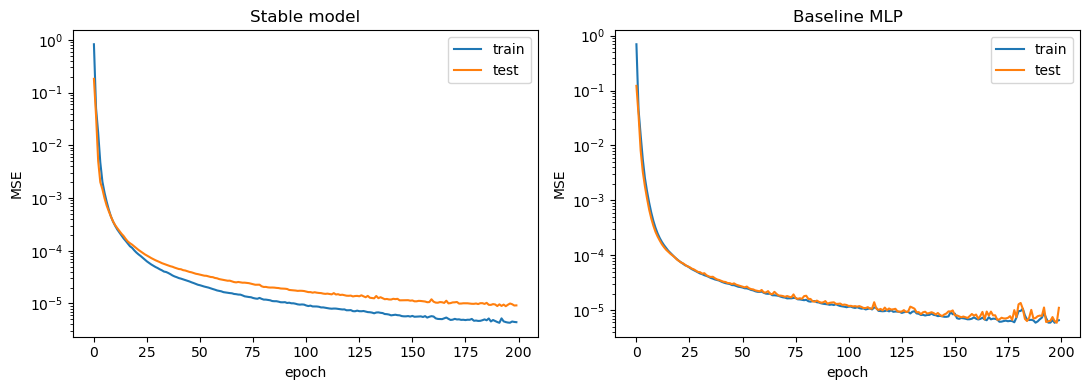

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_loss(stable_history, ax=axes[0], title="Stable model")
plot_loss(baseline_history, ax=axes[1], title="Baseline MLP")
plt.tight_layout()